In [55]:
#importing librabies
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score


In [56]:
#loading dataset
df=pd.read_csv("student_dropout_dataset_v3.csv")
df

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0


In [57]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [58]:
#handiling missing values
df["Family_Income"].fillna(df["Family_Income"].median(),inplace=True)


C:\Users\ROHAN\AppData\Local\Temp\ipykernel_12384\3609440865.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Family_Income"].fillna(df["Family_Income"].median(),inplace=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x24ddf902e90>,
 'caps': [<matplotlib.lines.Line2D at 0x24ddf903110>,
 'boxes': [<matplotlib.lines.Line2D at 0x24ddf902d50>],
 'medians': [<matplotlib.lines.Line2D at 0x24ddf903390>],
 'fliers': [<matplotlib.lines.Line2D at 0x24ddf9034d0>],
 'means': []}

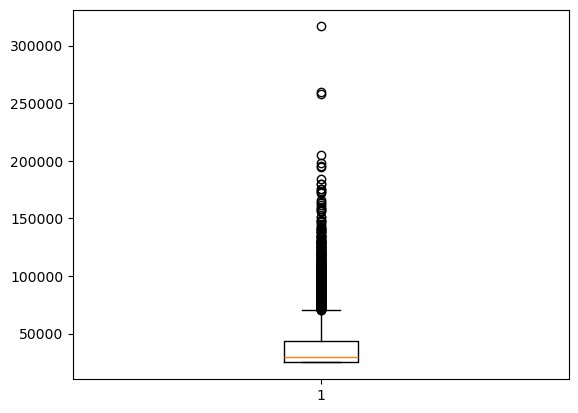

In [59]:
plt.boxplot(df["Family_Income"])

In [60]:
#removing outliers
Q1 = df["Family_Income"].quantile(0.25)
Q3 = df["Family_Income"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df["Family_Income"] >= lower_bound) & (df["Family_Income"] <= upper_bound)]


{'whiskers': [<matplotlib.lines.Line2D at 0x24ddf969f90>,
 'caps': [<matplotlib.lines.Line2D at 0x24ddf96a210>,
 'boxes': [<matplotlib.lines.Line2D at 0x24ddf969e50>],
 'medians': [<matplotlib.lines.Line2D at 0x24ddf96a490>],
 'fliers': [<matplotlib.lines.Line2D at 0x24ddf96a5d0>],
 'means': []}

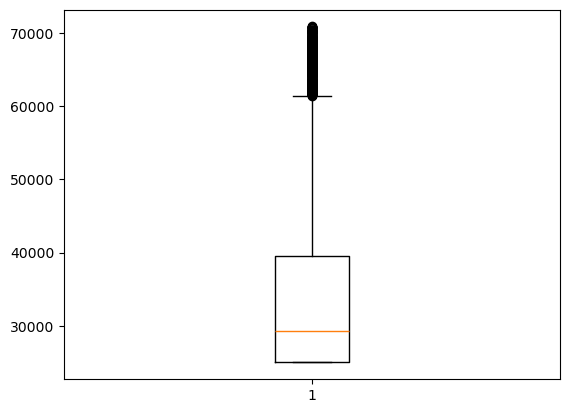

In [61]:
plt.boxplot(df["Family_Income"])

In [62]:
#removing outliers
Q1 = df["Family_Income"].quantile(0.25)
Q3 = df["Family_Income"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df["Family_Income"] >= lower_bound) & (df["Family_Income"] <= upper_bound)]

{'whiskers': [<matplotlib.lines.Line2D at 0x24ddfc50910>,
 'caps': [<matplotlib.lines.Line2D at 0x24ddfc50b90>,
 'boxes': [<matplotlib.lines.Line2D at 0x24ddfc507d0>],
 'medians': [<matplotlib.lines.Line2D at 0x24ddfc50e10>],
 'fliers': [<matplotlib.lines.Line2D at 0x24ddfc50f50>],
 'means': []}

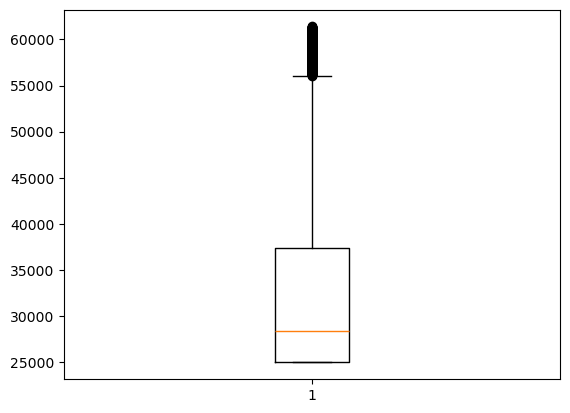

In [63]:
plt.boxplot(df["Family_Income"])

In [64]:
df.drop("Study_Hours_per_Day",axis=1,inplace=True)

In [65]:
df["Stress_Index"].fillna(df["Stress_Index"].median(),inplace=True)

C:\Users\ROHAN\AppData\Local\Temp\ipykernel_12384\325231955.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Stress_Index"].fillna(df["Stress_Index"].median(),inplace=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x24ddfcc0910>,
 'caps': [<matplotlib.lines.Line2D at 0x24ddfcc0b90>,
 'boxes': [<matplotlib.lines.Line2D at 0x24ddfcc07d0>],
 'medians': [<matplotlib.lines.Line2D at 0x24ddfcc0e10>],
 'fliers': [<matplotlib.lines.Line2D at 0x24ddfcc0f50>],
 'means': []}

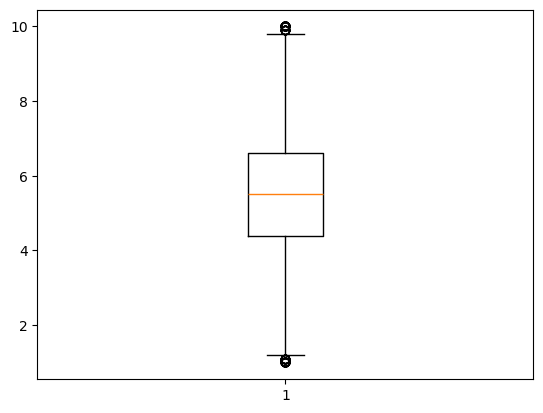

In [66]:
plt.boxplot(df["Stress_Index"])

In [67]:
# handling outliers in stress index
Q1 = df["Stress_Index"].quantile(0.25)
Q3 = df["Stress_Index"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df["Stress_Index"] >= lower_bound) & (df["Stress_Index"] <= upper_bound)]

{'whiskers': [<matplotlib.lines.Line2D at 0x24ddfcfb4d0>,
 'caps': [<matplotlib.lines.Line2D at 0x24ddfcfb750>,
 'boxes': [<matplotlib.lines.Line2D at 0x24ddfcfb390>],
 'medians': [<matplotlib.lines.Line2D at 0x24ddfcfb9d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x24ddfcfbb10>],
 'means': []}

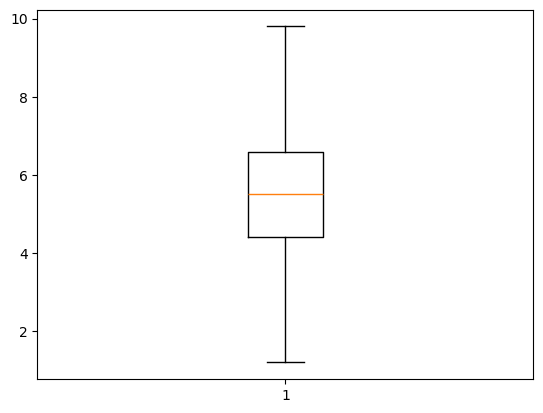

In [68]:
plt.boxplot(df["Stress_Index"])

In [70]:
df["Parental_Education"].unique()

array(['High School', 'Bachelor', 'Master', nan, 'PhD'], dtype=object)

In [71]:
df["Parental_Education"].fillna(df["Parental_Education"].mode()[0],inplace=True)

In [73]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [76]:
#converting categorical variable to numerical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df[df.select_dtypes(include=["object"]).columns] = df.select_dtypes(include=["object"]).apply(le.fit_transform)

In [75]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,29740.5,Yes,82.2,2,38.6,No,No,5.5,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [77]:
# splitting data into features and target variable
x=df.drop("Dropout",axis=1)
y=df["Dropout"]

In [78]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [79]:
# training the model
model = RandomForestClassifier()
model.fit(x_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
#predcting
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 1, 0], shape=(1763,))

In [82]:
#evaluation
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1352
           1       0.65      0.39      0.49       411

    accuracy                           0.81      1763
   macro avg       0.74      0.66      0.68      1763
weighted avg       0.79      0.81      0.79      1763

[[1268   84]
 [ 252  159]]
0.8094157685762904
